<a href="https://colab.research.google.com/github/admcculloch/ExerciseModel/blob/main/PCA_theory_and_sklearn_latent_structure_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis (PCA) with scikit-learn

This notebook follows the PCA theory derived from the lecture notes.

The key idea is that the observed measurements are generated from a small number of hidden (latent) variables. Individual measurements do not clearly separate the populations, but PCA can recover combinations of variables that reveal the underlying structure.


## 1. Data Matrix

Suppose we have an $n\times p$ data matrix

$$X$$

where rows are samples and columns are measured features.

For this demonstration we generate:

- 300 samples
- 10 observed features
- 2 hidden latent variables were used to synthesize these data so that they contain three overlapping populations not discriminated by the individual features themselves. These could represent three underlying biological variables that were not directly measured.

The observed features are mixtures of the latent variables plus noise:

$$
X = ZA + \epsilon
$$

where:

- $Z$ = latent variables
- $A$ = loading matrix
- $\epsilon$ = measurement noise


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_per_group = 100

latent_means = np.array([
    [-2.0, 0.0],
    [ 0.0, 1.8],
    [ 2.0,-0.8]
])

Z_list = []
labels = []

for i, mu in enumerate(latent_means):
    Z_list.append(np.random.multivariate_normal(
        mu,
        [[1.0,0.4],[0.4,1.0]],
        size=n_per_group
    ))
    labels.extend([i]*n_per_group)

Z = np.vstack(Z_list)
labels = np.array(labels)

A = np.array([
    [0.9, 0.7, 1.0, -0.8, 0.6, 0.3, -0.5, 0.4, 0.8, -0.4],
    [0.4,-0.6, 0.8,  0.5,-0.7, 1.0,  0.6,-0.3, 0.2,  0.9]
])

noise = np.random.normal(0,0.8,size=(len(Z),10))

X = Z @ A + noise

feature_names = [f'Feature {i+1}' for i in range(10)]
df = pd.DataFrame(X, columns=feature_names)

print("The full dataset contains 300 observations and 10 features",df.shape,". Five sampled observations are shown below:")
df.sample(5)


The full dataset contains 300 observations and 10 features (300, 10) . Five sampled observations are shown below:


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10
168,0.325228,-1.324146,3.673682,-0.320970,-1.471750,2.944286,1.582145,-0.548944,0.678271,2.874387
161,0.036594,-2.017793,3.148887,1.822818,-3.194353,3.704880,2.059734,-1.326682,2.036721,3.254528
4,-1.706586,-0.411828,-1.560085,0.665973,-1.822198,-0.099531,-0.791341,-1.012178,-1.570261,1.939684
155,0.515167,-0.514984,1.664170,1.812296,-3.068717,1.964951,1.460063,-1.197237,1.206345,2.939588
244,-0.108307,1.236660,-1.746619,-0.769396,1.845082,-3.336960,-0.162714,0.291814,0.079092,-0.640222


## 2. Visualizing the Raw Measurements

Before PCA, examine two measured variables.

Notice that the populations overlap substantially. A researcher looking only at these two variables would not immediately discover the three groups.

This motivates dimensionality reduction.


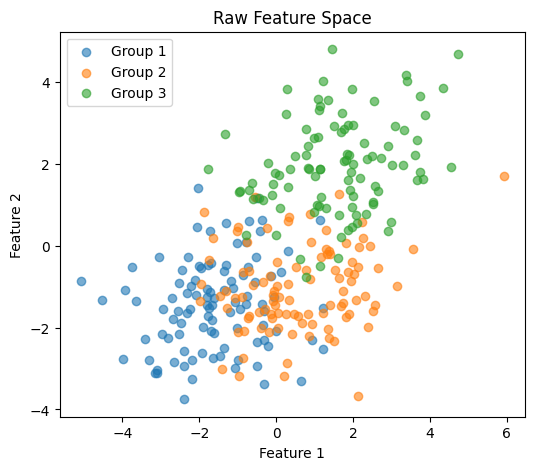

In [24]:
plt.figure(figsize=(6,5))

for g in range(3):
    idx = labels == g
    plt.scatter(
        X[idx,0],
        X[idx,1],
        alpha=0.6,
        label=f'Group {g+1}'
    )

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Raw Feature Space')
plt.legend()
plt.show()


## 3. Correlated Features

PCA is most useful when variables contain overlapping information.

The heatmap below shows that many of the measurements are correlated because they arise from the same underlying latent variables.


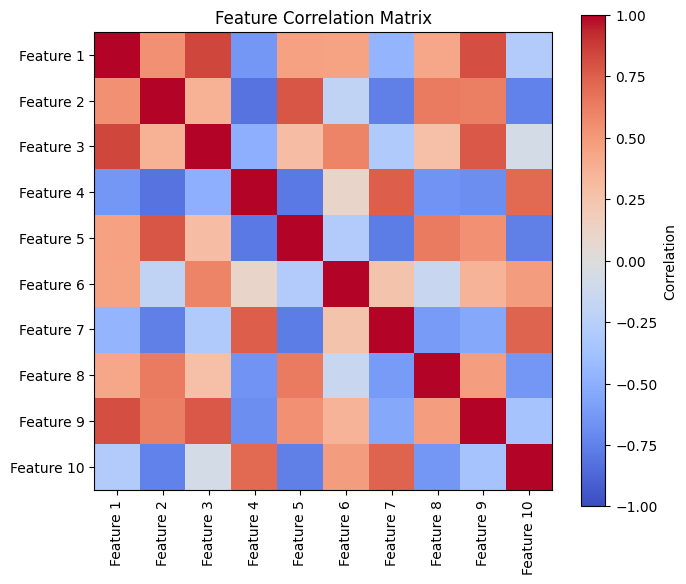

In [ ]:
corr = df.corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(10), feature_names, rotation=90)
plt.yticks(range(10), feature_names)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 4. PCA Theory and the scikit-learn Implementation

After centering the data, PCA computes the singular value decomposition (SVD)

$$
X = U \Sigma V^T
$$

and the covariance matrix can be written as

$$
C
=
V
\left(
\frac{\Sigma^2}{n-1}
\right)
V^T.
$$

The principal components are the columns of $V$, and the variance explained by each principal component is

$$
\frac{\sigma_i^2}{n-1},
$$

where $\sigma_i$ is the corresponding singular value.

scikit-learn computes the decomposition internally and provides access to the key quantities through the `PCA` object.

The table below summarizes the relationship between the mathematical formulation and the scikit-learn implementation.

| Mathematical Quantity | Meaning | scikit-learn |
|----------------------|---------|-------------|
| $X$| Centered data matrix | `X` |
| $V$ | Principal directions | `pca.components_.T` |
| $\Sigma$ | Singular values | `pca.singular_values_` |
| $\frac{\sigma_i^2}{n-1}$ | Variance explained by PC $i$| `pca.explained_variance_` |
| $Z = XV$ | Coordinates in PC space | `pca.fit_transform(X)` |

The following code computes the PCA and extracts these quantities.


In [25]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=10)
scores = pca.fit_transform(X)
explained_variance = pca.explained_variance_ratio_
summary = pd.DataFrame({
    "Singular Value": pca.singular_values_,
    "Variance Explained": pca.explained_variance_,
    "Variance Ratio": pca.explained_variance_ratio_
})

summary.index = [f"PC{i+1}" for i in range(10)]
summary.round(4)


,Singular Value,Variance Explained,Variance Ratio
PC1,72.9606,17.8035,0.5703
PC2,50.2685,8.4513,0.2707
PC3,15.2397,0.7768,0.0249
PC4,14.7391,0.7266,0.0233
PC5,14.5297,0.7061,0.0226
PC6,13.7556,0.6328,0.0203
PC7,13.1330,0.5768,0.0185
PC8,12.6803,0.5378,0.0172
PC9,12.4558,0.5189,0.0166
PC10,12.0887,0.4887,0.0157


The table above contains the key outputs of PCA.

- The singular values correspond to the diagonal entries of $\Sigma$.
- The explained variances correspond to $\frac{\sigma_i^2}{(n-1)}$.
- The explained variance ratios indicate the fraction of total variance captured by each principal component.
- The matrix `scores` contains the coordinates of each observation in principal-component space and will be used for visualization below.

## 5. Variance Explained (Scree Plot)

Because the synthetic dataset was generated from two latent variables, most of the variance should be captured by the first two principal components.


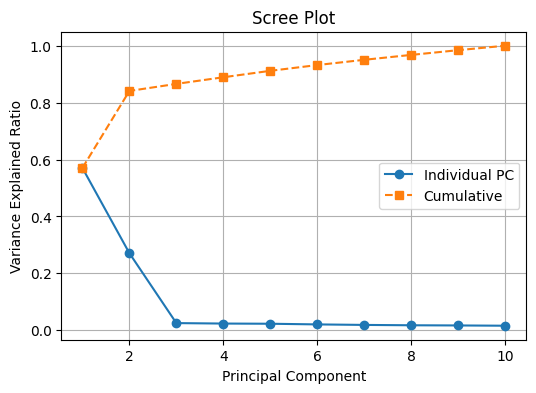

Cumulative variance explained by first two PCs: 0.8409811224478421


In [26]:
variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

plt.figure(figsize=(6,4))

plt.plot(
    np.arange(1, len(variance_ratio) + 1),
    variance_ratio,
    'o-',
    label='Individual PC'
)

plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    's--',
    label='Cumulative'
)

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

print(
    'Cumulative variance explained by first two PCs:',
    cumulative_variance[1]
)

## 6. PCA Projection

The transformed coordinates are

```python
scores = pca.fit_transform(X)
```

which correspond mathematically to

$$
Z = XV
$$

If PCA successfully recovers the latent structure, the populations should separate more clearly in the PC space than they did in the original measurements.


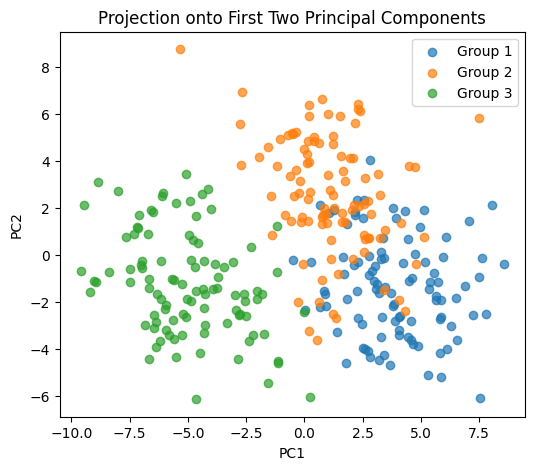

In [27]:
plt.figure(figsize=(6,5))

for g in range(3):
    idx = labels == g
    plt.scatter(
        scores[idx,0],
        scores[idx,1],
        alpha=0.7,
        label=f'Group {g+1}'
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projection onto First Two Principal Components')
plt.legend()
plt.show()


## 7. Interpreting the Loadings

The rows of

```python
pca.components_
```

correspond to the principal directions.

Large positive or negative values indicate features that contribute strongly to a principal component.


In [28]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=feature_names,
    columns=['PC1','PC2']
)

loadings


,PC1,PC2
Feature 1,-0.359726,0.306992
Feature 2,-0.382606,-0.192265
Feature 3,-0.355247,0.515723
Feature 4,0.404960,0.111258
Feature 5,-0.336367,-0.232025
Feature 6,-0.024291,0.556280
Feature 7,0.292203,0.189449
Feature 8,-0.183337,-0.099458
Feature 9,-0.341618,0.208253
Feature 10,0.290837,0.371492
